In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv("/Users/Yashwanth.B/jupyter/datasets/restaurant_tips.csv")
data_size = df.shape
print(f'(rows,colums) {data_size}')
df.head()

(rows,colums) (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Outliers

- Step 1 - Null check
- Step 2 - Use boxplot to get check % of outliers
- Step 3 - Quantile threshold
- Step 4 - Mean & Standard deviation threshold
- Step 5 - All Catgeories reshaping data using hot encoding
- Step 6 - Predit model using fit


#### More info about outlier

- If skew > 0.5 or < -0.5 → use IQR/quantile
- If skew near 0 → z-score is okay → mean & std

Note - Don't remove complete outliers, choose skew vs IQR gives limited outliers, so model can handle both 

In [4]:
#null check
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

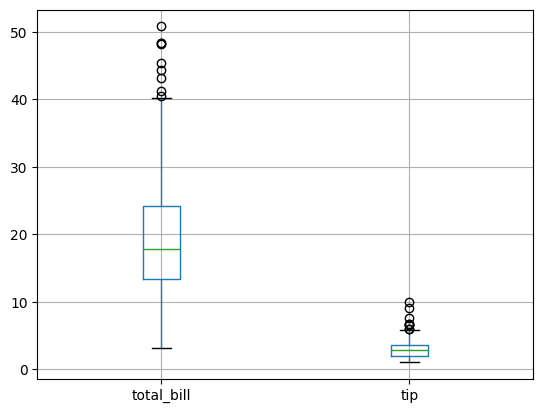

In [5]:
plt.close()
df[["total_bill", "tip"]].boxplot() # In visulization, there are more then  need to calculate % of outliers
plt.show()

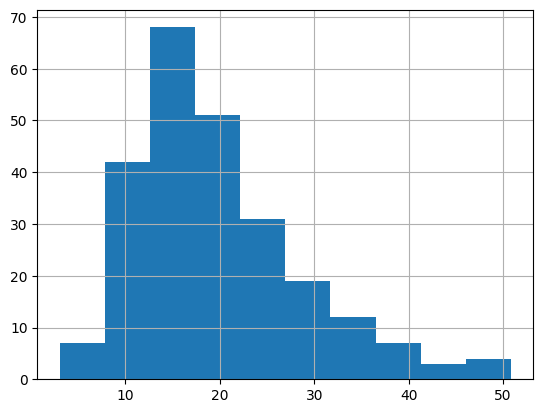

In [6]:
df["total_bill"].hist()
plt.show()

In [7]:
print(df["tip"].skew())

1.4654510370979401


In [8]:
# To get percentage of these outliers
totalbill_min_threshold, totalbill_max_threshold = df["total_bill"].quantile([0.01, 0.99])
print(f"totalbill_min_threshold {totalbill_min_threshold}")
print(f"totalbill_max_threshold {totalbill_max_threshold}")

total_bill_outliers = ((df["total_bill"] < totalbill_min_threshold) | (df["total_bill"] > totalbill_max_threshold)).mean()*100
print(f"total_bill_outliers {total_bill_outliers}")

# if outlier mean() <= 2% its less outliers
# if outlier mean() > 2% to < 8% its moderate outliers then quantile range should ([0.01, 0.99])
# if outlier mean() > 10% then we need to revist the data, clear some unuse etc

totalbill_min_threshold 7.25
totalbill_max_threshold 48.227000000000004
total_bill_outliers 2.0491803278688523


In [9]:
tips_min_threshold, tips_max_threshold = df["tip"].quantile([0.01, 0.99])

outliers_percentage = ((df["tip"] < tips_min_threshold) | (df["tip"] > tips_max_threshold)).mean()*100
print(f"outliers_percentage {outliers_percentage}")

outliers_percentage 1.2295081967213115


In [10]:
df = df[(df["total_bill"] > totalbill_min_threshold) & (df["total_bill"] < totalbill_max_threshold)]
df = df[(df["tip"] > tips_min_threshold) & (df["tip"] < tips_max_threshold)]
df.shape

(235, 7)

In [11]:
# mean & standard deviation
total_bill_std = df["total_bill"].std()
print("mean: ", df["total_bill"].mean())
print("standard devaition: ",df["total_bill"].std())

std_min_threshold = df["total_bill"].mean() - (3 * total_bill_std)
std_max_thresshold = df["total_bill"].mean() + (3 * total_bill_std)
print("std_min_threshold: ", std_min_threshold)
print("std_max_thresshold: ",std_max_thresshold)

std_min_threshold = df["tip"].mean() - (3* df["tip"].std())
std_max_thrshold = df["tip"].mean() + (3*df["tip"].std())

df = df[(df["total_bill"] > std_min_threshold) & (df["total_bill"] < std_max_thresshold)]
df = df[(df["tip"] > std_min_threshold) & (df["tip"] < std_max_thrshold)]

df.shape

mean:  19.595829787234045
standard devaition:  8.121278769983991
std_min_threshold:  -4.768006522717929
std_max_thresshold:  43.959666097186016


(229, 7)

In [12]:
# Hot encoding

categories = ["sex", "smoker", "day", "time"]
for category in categories:
    category_split = pd.get_dummies(df[category], prefix=category)
    df = pd.concat([df, category_split], axis=1)
df = df.drop(columns=categories)

In [13]:
df.head()

,total_bill,tip,size,sex_Female,sex_Male,smoker_No,smoker_Yes,day_Fri,day_Sat,day_Sun,day_Thur,time_Dinner,time_Lunch
0,16.99,1.01,2,True,False,True,False,False,False,True,False,True,False
1,10.34,1.66,3,False,True,True,False,False,False,True,False,True,False
2,21.01,3.50,3,False,True,True,False,False,False,True,False,True,False
3,23.68,3.31,2,False,True,True,False,False,False,True,False,True,False
4,24.59,3.61,4,True,False,True,False,False,False,True,False,True,False


In [14]:
from xgboost import XGBRegressor
import time

x = df.drop(columns=["tip"])
y = df["tip"]
start = time.time()
model = XGBRegressor()
model.fit(x,y)
end = time.time()
print(f"time taken in seconds: {end-start}")

time taken in seconds: 0.2019789218902588


In [19]:
df2 = df.drop(columns=["tip"])
model.predict(df2)

df2["predict"] = model.predict(df2)
df2.head()

,total_bill,size,sex_Female,sex_Male,smoker_No,smoker_Yes,day_Fri,day_Sat,day_Sun,day_Thur,time_Dinner,time_Lunch,predict
0,16.99,2,True,False,True,False,False,False,True,False,True,False,1.115821
1,10.34,3,False,True,True,False,False,False,True,False,True,False,1.650271
2,21.01,3,False,True,True,False,False,False,True,False,True,False,3.495957
3,23.68,2,False,True,True,False,False,False,True,False,True,False,3.302098
4,24.59,4,True,False,True,False,False,False,True,False,True,False,3.578707


In [21]:
df2.to_csv("restaurant_tips_prediction", index=False)